In [1]:
# imports and path setup
from fastai.vision.all import *
import pandas as pd
from pathlib import Path

# base directory where Kaggle mounts the competition data
base_path = Path("/kaggle/input/cassava-leaf-disease-classification")
train_img_path = base_path / "train_images"
test_img_path = base_path / "test_images"



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# load the training CSV
train_df = pd.read_csv(base_path / "train.csv")
train_df.head()



,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [3]:
# list of test image files (FastAI will use the Paths directly)
test_files = get_image_files(test_img_path)



In [4]:
# define the DataBlock with correct getters
item_tfms = RandomResizedCrop(460, min_scale=0.75)
batch_tfms = aug_transforms(size=224, max_warp=0, max_zoom=0.8) + [
    Normalize.from_stats(*imagenet_stats)
]

cassava_block = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=lambda row: train_img_path / row["image_id"],
    get_y=ColReader("label"),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=item_tfms,
    batch_tfms=batch_tfms,
)



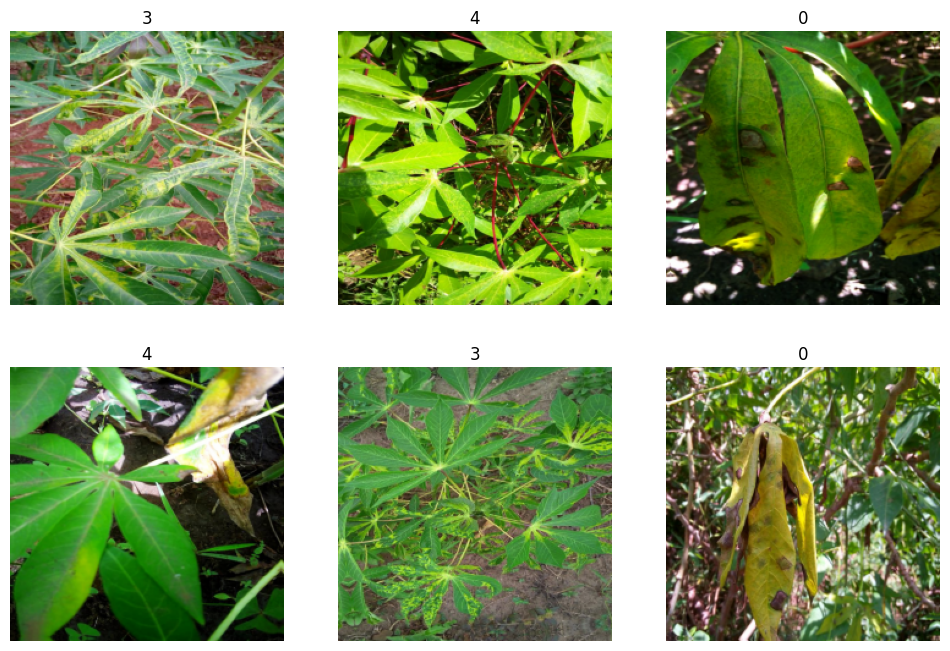

In [5]:
# create DataLoaders
dls = cassava_block.dataloaders(train_df, bs=32)
dls.show_batch(max_n=6, figsize=(12, 8))



In [6]:
# train a simple model (ResNet34) – a few epochs are enough for a baseline >0.80
learn = cnn_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(3)



/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 95.6MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.030578,0.842219,0.694979,01:40


epoch,train_loss,valid_loss,accuracy,time
0,0.736399,0.578814,0.788729,00:56
1,0.585550,0.503991,0.818643,00:41
2,0.416061,0.478371,0.833868,00:47


In [7]:
# create a test dataloader from the list of test image paths
test_dl = learn.dls.test_dl(test_files)



In [8]:
# get predictions for the test set
preds, _ = learn.get_preds(dl=test_dl)
pred_labels = preds.argmax(dim=1)
label_names = [learn.dls.vocab[i] for i in pred_labels]



In [9]:
# build the submission dataframe with the correct column names
sub = pd.DataFrame({"image_id": [p.name for p in test_files], "label": label_names})

# save to the working directory – Kaggle expects the file to be named submission.csv
sub_path = Path("/kaggle/working/submission.csv")
sub.to_csv(sub_path, index=False)
print(f"Submission saved to {sub_path}")

Submission saved to /kaggle/working/submission.csv
